# Smoothing / Filtering :
# Lissage / filtrage :

**Local smoothing (or filtering) consists of removing noise present in an image by studying, for each pixel, the intensity values ​​in its neighborhood.**


**Le lissage local (ou filtrage) consiste à supprimer le bruit présent dans une image
en étudiant, pour chaque pixel, les valeurs d’intensité sur son voisinage.**

### Upload packages / importer les packages 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from math import sqrt
import cv2 as cv


### chargement d'image 

les dimension de l'image :  (576, 768)
l'hauteur de l'image :  576
largeur de l'image : 768


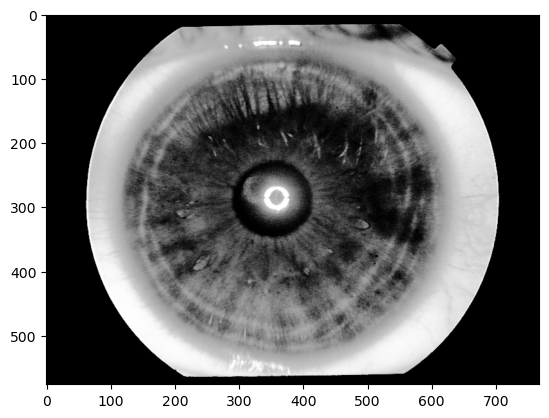

In [20]:
## 0 for reading the image in grayscale mode
img = cv.imread('contrast.png',0)
## dimension de l'image
dimensions = img.shape
print("les dimension de l'image : ", dimensions)
## zidth and height of image / largeur et hauteur de l'image
height = img.shape[0]
width = img.shape[1]
print("l'hauteur de l'image : ",height)
print("largeur de l'image :",width)
## afichage de l'image
plt.imshow(img, cmap=plt.get_cmap('gray'))

# Average filter / filtre moyenne


One approach is based on information redundancy. The new value of a pixel is calculated by averaging the values ​​over a neighborhood. This linear operation can be seen as the discrete convolution of the image with a mask.

Une première classe d’approche est basée la redondance d’informations. La nouvelle valeur d’un pixel est calculée par moyennage des valeurs sur un voisinage.
Cette opération linéaire peut être vue comme la convolution discrète de l’image par un masque.


$$ I^{'}(i,j) = \sum_{(m,n)\in V}I(m,n)(i-m,j-n)$$ 
$$ \sum_{(m,n)\in V}I(m,n)=1$$ 



where I is the intensity of the original image,  $I^{′}$  is the intensity of the filtered image, $V$is the neighborhood used, and h is the convolution mask.

ou I est l’intensité de l’image d’origine, $I^{′}$ est l’intensité de l’image filtrée, $V$ est le voisinage utilisé et h est le masque de convolution.


In [21]:
def filtre_moy(img):
    # Develop Averaging filter(3, 3) mask
    Filter_mask = np.full((3, 3), 1/9)
    # Obtenir le nombre de ligne et colonne 
    m, n = img.shape
    #l'image sortie
    outputImage = np.zeros([m, n])
    #modification de l'image 
    for i in range(1, m-1):
        for j in range(1, n-1):
            temp = 0
            for k in range(3):
                for l in range(3):
                    temp += Filter_mask [k, l]*img[i -1 + k , j - 1 + l]
                    outputImage[i, j] = temp
    return outputImage

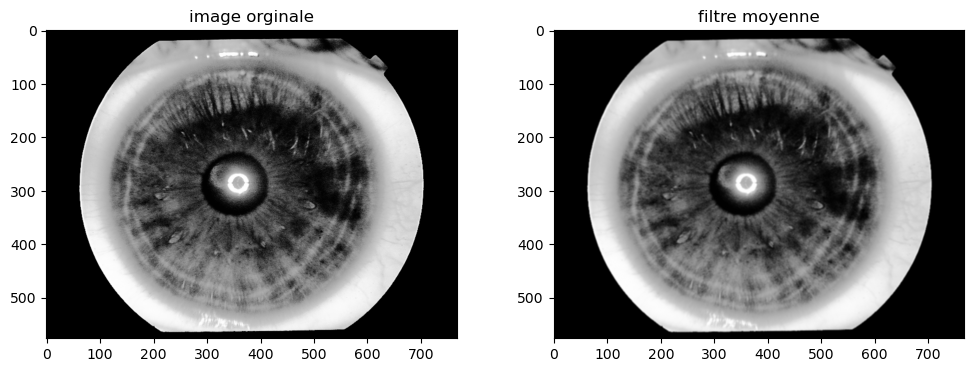

In [22]:
res = filtre_moy(img)
# The graphics 
_, axis = plt.subplots(ncols=2, figsize=(12, 4))
axis[0].imshow(img, cmap=plt.get_cmap('gray'))
axis[1].imshow(res, cmap=plt.get_cmap('gray'))
axis[0].set_title('image orginale')
axis[1].set_title('filtre moyenne')
plt.show()

## Median filter / Median filter

**EN** Averaging filters tend to blur the image and therefore lose information about edges characterized by strong intensity variations. To reduce this effect, instead of averaging over the neighborhood, we take the median value of that neighborhood. This is the median filter.

The main idea of **the median filter** is to replace each input with the median value of its neighborhood.

**FR** Les filtres de moyennage ont tendance à rendre l’image floue et donc à perdre de l’informations sur les contours caractérisés par des fortes variations d’intensité.
Pour diminuer cet effet, on ne moyenne plus sur le voisinage mais on prend la
valeur médiane sur ce voisinage. C’est le filtre médian.

L'idée principale du filtre médian est de remplacer chaque entrée par la valeur médiane de son voisinage.

In [23]:
def median_filter(img, kernel_size):
    temp = []
    indexer = kernel_size // 2
    # Obtenir le nombre de ligne et colonne 
    m, n = img.shape
    #l'image sortie
    outputImage = np.zeros([m, n])
    for i in range(m):
        for j in range(n):
            for z in range(kernel_size):
                if i + z - indexer < 0 or i + z - indexer > m - 1:
                    for c in range(kernel_size):
                        temp.append(0)
                else:
                    if j + z - indexer < 0 or j + indexer > n - 1:
                        temp.append(0)
                    else:
                        for k in range(kernel_size):
                            temp.append(img[i + z - indexer][j + k - indexer])
            temp.sort()
            outputImage[i][j] = temp[len(temp) // 2]
            temp=[]
    return outputImage

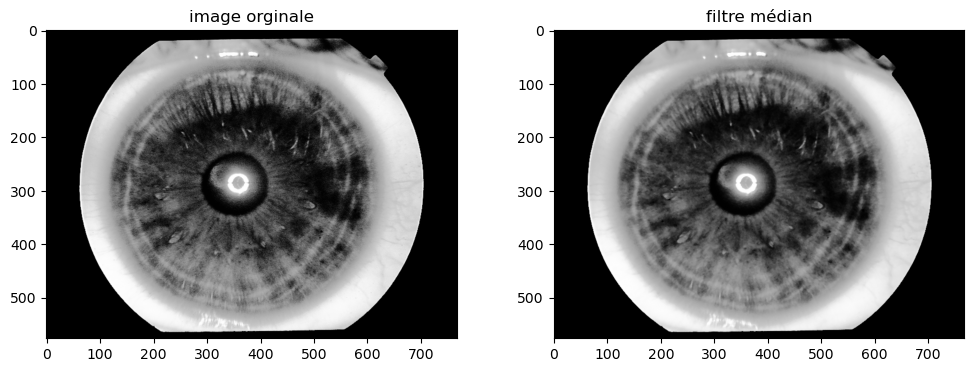

In [24]:
img_filtre_median = median_filter(np.array(img), 3) 
# The graphics 
_, axis = plt.subplots(ncols=2, figsize=(12, 4))
axis[0].imshow(img, cmap=plt.get_cmap('gray'))
axis[1].imshow(img_filtre_median, cmap=plt.get_cmap('gray'))
axis[0].set_title('image orginale')
axis[1].set_title('filtre médian')
plt.show()

In [26]:
def filtre_median(img):
    # Obtenir le nombre de ligne et colonne 
    m, n = img.shape
    prop = img.shape
    #we take a window and find the median of intensity values 
    #in that window and assigned it to the current pixel
    new_img = np.zeros([m, n])
    ############### 3x3 window ############### 
    for i in range(1, prop[0] - 1):
        for j in range(1, prop[1] - 1):
            win = []
            for x in range(i-1, i + 2):
                for y in range(j-1, j+2):
                    win.append( img[x][y] )
            #sort the values
            win.sort()
            new_img[i][j] = win[4]
    return new_img

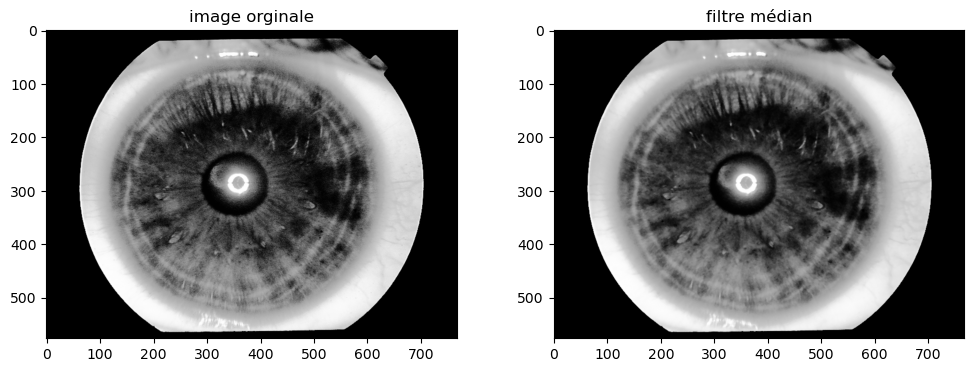

In [27]:
med = filtre_median(img)
# The graphics 
_, axis = plt.subplots(ncols=2, figsize=(12, 4))
axis[0].imshow(img, cmap=plt.get_cmap('gray'))
axis[1].imshow(med, cmap=plt.get_cmap('gray'))
axis[0].set_title('image orginale')
axis[1].set_title('filtre médian')
plt.show()

## gaussian kernel

In [28]:
from numpy import dot, exp, mgrid, pi, ravel, square, uint8, zeros

In [29]:
def gen_gaussian_kernel(k_size, sigma):
    center = k_size // 2
    x, y = mgrid[0 - center : k_size - center, 0 - center : k_size - center]
    g = 1 / (2 * pi * sigma) * exp(-(square(x) + square(y)) / (2 * square(sigma)))
    return g

In [30]:
def gaussian_filter(image, k_size, sigma):
    height, width = image.shape[0], image.shape[1]
    # dst image height and width
    dst_height = height - k_size + 1
    dst_width = width - k_size + 1

    # im2col, turn the k_size*k_size pixels into a row and np.vstack all rows
    image_array = np.zeros((dst_height * dst_width, k_size * k_size))
    row = 0
    for i in range(dst_height):
        for j in range(dst_width):
            window = np.ravel(image[i : i + k_size, j : j + k_size])
            image_array[row, :] = window
            row += 1

    #  turn the kernel into shape(k*k, 1)
    gaussian_kernel = gen_gaussian_kernel(k_size, sigma)
    filter_array = np.ravel(gaussian_kernel)

    # reshape and get the dst image
    dst = dot(image_array, filter_array).reshape(dst_height, dst_width).astype(uint8)

    return dst

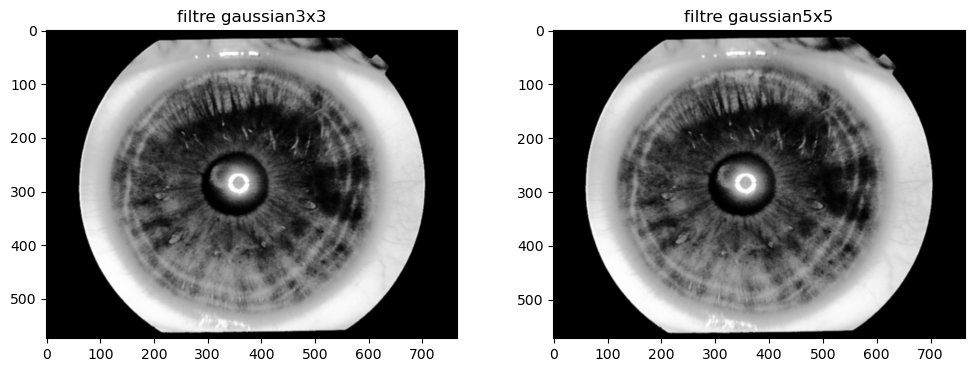

In [31]:
 # get values with two different mask size
gaussian3x3 = gaussian_filter(img, 3, sigma=1)
gaussian5x5 = gaussian_filter(img, 5, sigma=0.8)

# The graphics 
_, axis = plt.subplots(ncols=2, figsize=(12, 4))
axis[0].imshow(gaussian3x3, cmap=plt.get_cmap('gray'))
axis[1].imshow(gaussian5x5, cmap=plt.get_cmap('gray'))
axis[0].set_title('filtre gaussian3x3')
axis[1].set_title('filtre gaussian5x5')
plt.show()

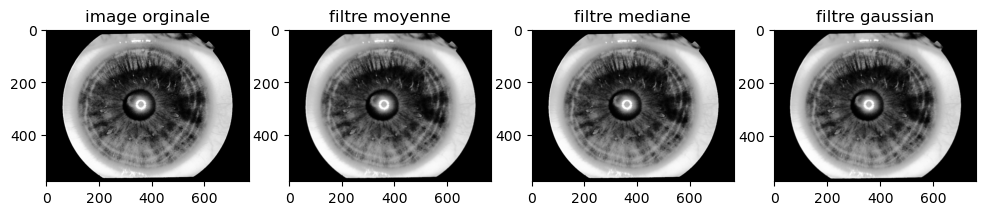

In [32]:
# The graphics 
_, axis = plt.subplots(ncols=4, figsize=(12, 4))
axis[0].imshow(img, cmap=plt.get_cmap('gray'))
axis[1].imshow(res, cmap=plt.get_cmap('gray'))
axis[2].imshow(med, cmap=plt.get_cmap('gray'))
axis[3].imshow(gaussian5x5, cmap=plt.get_cmap('gray'))
axis[0].set_title('image orginale')
axis[1].set_title('filtre moyenne')
axis[2].set_title('filtre mediane')
axis[3].set_title('filtre gaussian')
plt.show()

# Sobel filter (Edge detection)/ filtre de sobel(Détection des contours)

Another use of linear filters is to highlight edges in an image. This is done using kernels that calculate the difference between the gray levels in one direction and the gray levels in the opposite direction.

The final edge image is obtained by combining the edge images for each direction. A practical combination is to calculate the magnitude of the orthogonal directions:

$$ I^{'} = \sqrt{H_0(I)^2 + H_{90}(I)^2} $$




Une autre utilisation des filtres linéaires est de mettre en évidence les contours dans une image. Pour cela on utilise des noyaux qui calculent la différence entre les niveaux de gris dans une direction, et les niveaux de gris dans la direction opposée.
L'image finale des contours est obtenue en combinant les images de contours pour chaque direction. Une combinaison pratique est de calculer le module des directions orthogonales :

$$ I^{'} = \sqrt{H_0(I)^2 + H_{90}(I)^2} $$


In [33]:
# Sobel kernels
kernely = [[-1, 0, 1],[-2, 0, 2],[-1, 0, 1]]
kernelx = [[-1, -2, -1],[0, 0, 0],[1, 2, 1]]

In [34]:
def sobel_filter (img, kernelx, kernely):
    input_image = Image.fromarray(img) ## from cv to pil
    input_pixels = input_image.load()
    output_image = Image.new("RGB", input_image.size) 
    draw = ImageDraw.Draw(output_image)

    # Compute convolution between intensity and kernels
    for x in range(1, input_image.width - 1):
        for y in range(1, input_image.height - 1):
            magx, magy = 0, 0
            for a in range(3):
                for b in range(3):
                    xn = x + a - 1
                    yn =  y + b - 1
                    intensity = input_pixels[xn,yn]
                    intensity = np.sum(intensity) / 3
                    magx += intensity * kernelx[a][b]
                    magy += intensity * kernely[a][b]

            # Draw in black and white the magnitude
            color = int(sqrt(magx**2 + magy**2))
            draw.point((x, y), (color, color, color))   
    return output_image ## reverser l'operation from pill to cv


In [35]:
output_image = sobel_filter (img, kernelx, kernely)
sobel = np.asarray(output_image) 
cv.imwrite("sobel3.png",sobel)

True

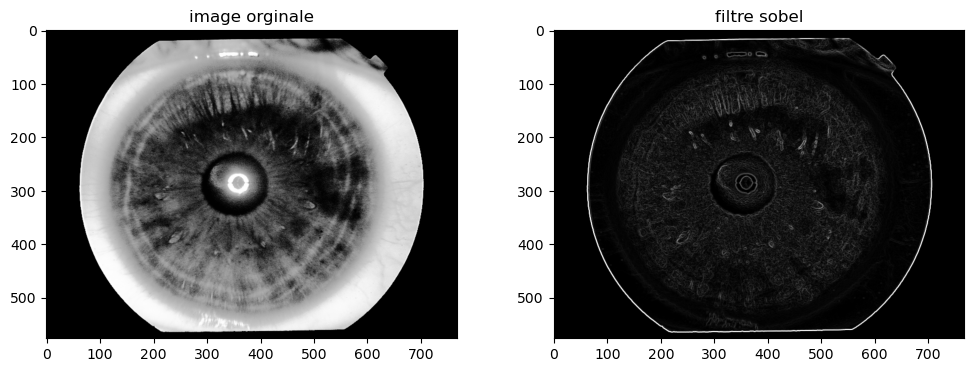

In [36]:

# The graphics 
_, axis = plt.subplots(ncols=2, figsize=(12, 4))
axis[0].imshow(img, cmap=plt.get_cmap('gray'))
axis[1].imshow(output_image, cmap=plt.get_cmap('gray'))
axis[0].set_title('image orginale')
axis[1].set_title('filtre sobel')
plt.show()

#### Save images / enregister les images :

In [37]:
#### enregister les images :
cv.imwrite('filtre moy.png',res)
cv.imwrite('filtre med.png',med)
cv.imwrite('filtre gaussian.png',gaussian5x5)
cv.imwrite("sobel3.png",sobel)

True